<center>
<img src="https://laelgelcpublic.s3.sa-east-1.amazonaws.com/lael_50_years_narrow_white.png.no_years.400px_96dpi.png" width="300" alt="LAEL 50 years logo">
<h3>APPLIED LINGUISTICS GRADUATE PROGRAMME (LAEL)</h3>
</center>
<hr>

# Corpus Linguistics - Study 2 - Phase 3 - Elaine

This document aims to preparing data for a Textual Lexical Multi-Dimensional Analysis.

## Required Python packages

- pandas

## Import the required libraries

In [20]:
import pandas as pd
import os
import sys
import logging
import nltk
from nltk.tokenize import word_tokenize
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Define input variables

In [17]:
input_directory = 'CoTED2_TED_TEDEX_1984_2025'
output_directory = 'cl_st2_ph3_elaine'
dataset_filename_1 = 'cl_st2_ph3_elaine_extracted'
dataset_filename_2 = 'cl_st2_ph3_elaine_dataset'

## Create output directory

In [3]:
# Check if the output directory already exists. If it does, do nothing. If it doesn't exist, create it.
if os.path.exists(output_directory):
    print('Output directory already exists.')
else:
    try:
        os.makedirs(output_directory)
        print('Output directory successfully created.')
    except OSError as e:
        print('Failed to create the directory:', e)
        sys.exit(1)

Output directory already exists.


## Set up logging

In [4]:
log_filename = f"{output_directory}/{output_directory}.log"

In [5]:
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    filename=log_filename
)

## Import the directory structure into a DataFrame

In [6]:
# Initialising an empty list to hold the directory information
directory_data = []

# Walking through the directory structure
for root, dirs, files in os.walk(input_directory):
    #for file in tqdm(files, desc='Processing files'):
    for file in files:
        if file.endswith('.txt'):
            try:
                # Getting the full file path
                file_path = os.path.join(root, file)
                # Splitting the root into individual directories
                directory_parts = root.split(os.sep)
                # Creating a dictionary for this file's information
                file_info = {'File': file}
                # Adding the file path to the dictionary
                file_info['File Path'] = file_path
                # Adding each part of the directory to the dictionary with appropriate keys
                for i, part in enumerate(directory_parts):
                    file_info[f"Directory Level {i + 1}"] = part

                # Reading the text file
                with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
                    text = f.read()

                file_info['Text'] = text

                # Adding the file info to the list
                directory_data.append(file_info)

                # Logging the successful extraction
                logging.info(f"Successfully extracted {file_path}")
            except Exception as e:
                # Logging any errors
                logging.error(f"Error extracting {file_path}: {str(e)}")

# Converting the list of dictionaries into a DataFrame
df = pd.DataFrame(directory_data)

In [7]:
df

,File,File Path,Directory Level 1,Text
0,T3203_RO_TED_MED_2012.txt,CoTED2_TED_TEDEX_1984_2025/T3203_RO_TED_MED_20...,CoTED2_TED_TEDEX_1984_2025,So my freshman year of college I signed up for...
1,T5313_JC_TED_MONTEREY_2021.txt,CoTED2_TED_TEDEX_1984_2025/T5313_JC_TED_MONTER...,CoTED2_TED_TEDEX_1984_2025,If you live in New York or London or some oth...
2,T1220_LT_TEDX_PALOA_2017.txt,CoTED2_TED_TEDEX_1984_2025/T1220_LT_TEDX_PALOA...,CoTED2_TED_TEDEX_1984_2025,You only get one chance to make a first impres...
3,T4048_CL_TED_AIV_2024.txt,CoTED2_TED_TEDEX_1984_2025/T4048_CL_TED_AIV_20...,CoTED2_TED_TEDEX_1984_2025,How often are you frustrated by the time it ta...
4,T5231_JP_TED_TWWW_2021.txt,CoTED2_TED_TEDEX_1984_2025/T5231_JP_TED_TWWW_2...,CoTED2_TED_TEDEX_1984_2025,Running a business means being a constant prob...
...,...,...,...,...
4312,T1788_JG_TED_LIVE_2015.txt,CoTED2_TED_TEDEX_1984_2025/T1788_JG_TED_LIVE_2...,CoTED2_TED_TEDEX_1984_2025,Is there life beyond Earth in our solar system...
4313,T1001_MM_TEDX_E_2017.txt,CoTED2_TED_TEDEX_1984_2025/T1001_MM_TEDX_E_201...,CoTED2_TED_TEDEX_1984_2025,I'm a 26-year-old British Asian woman working ...
4314,T3386_SR_TEDX_MIA_2011.txt,CoTED2_TED_TEDEX_1984_2025/T3386_SR_TEDX_MIA_2...,CoTED2_TED_TEDEX_1984_2025,So what makes a piece of music beautiful? Well...
4315,T0387_RF_TED_2005.txt,CoTED2_TED_TEDEX_1984_2025/T0387_RF_TED_2005.txt,CoTED2_TED_TEDEX_1984_2025,I want you to imagine that you're a student in...


In [8]:
# Sort the DataFrame by 'File' in ascending order and display it
df = df.sort_values(by='File', ascending=True, ignore_index=True)
df

,File,File Path,Directory Level 1,Text
0,T0004_AM_TED_2019.txt,CoTED2_TED_TEDEX_1984_2025/T0004_AM_TED_2019.txt,CoTED2_TED_TEDEX_1984_2025,I spent the past three years talking to some o...
1,T0006_AV_TED_2019.txt,CoTED2_TED_TEDEX_1984_2025/T0006_AV_TED_2019.txt,CoTED2_TED_TEDEX_1984_2025,[This is an improvised talk (and intro) based ...
2,T0007_AAB_TED_2019.txt,CoTED2_TED_TEDEX_1984_2025/T0007_AAB_TED_2019.txt,CoTED2_TED_TEDEX_1984_2025,So one of the most important solutions to the ...
3,T0008_BV_TED_2019.txt,CoTED2_TED_TEDEX_1984_2025/T0008_BV_TED_2019.txt,CoTED2_TED_TEDEX_1984_2025,"So in the winter of 2012, I went to visit my g..."
4,T0009_BW_TED_RES_2019.txt,CoTED2_TED_TEDEX_1984_2025/T0009_BW_TED_RES_20...,CoTED2_TED_TEDEX_1984_2025,For all that's ever been said about climate ch...
...,...,...,...,...
4312,T5897_CH_TED_TWWW_2020.txt,CoTED2_TED_TEDEX_1984_2025/T5897_CH_TED_TWWW_2...,CoTED2_TED_TEDEX_1984_2025,I was not one of those kids that knew exactly ...
4313,T5898_EO_TED_TWWW_2020.txt,CoTED2_TED_TEDEX_1984_2025/T5898_EO_TED_TWWW_2...,CoTED2_TED_TEDEX_1984_2025,"When I was pregnant, I just got very frustrate..."
4314,T5899_TD_TED_TWWW_2020.txt,CoTED2_TED_TEDEX_1984_2025/T5899_TD_TED_TWWW_2...,CoTED2_TED_TEDEX_1984_2025,When you think about money and your dreams and...
4315,T5900_LR_TED_TWWW_2020.txt,CoTED2_TED_TEDEX_1984_2025/T5900_LR_TED_TWWW_2...,CoTED2_TED_TEDEX_1984_2025,"If you look at a carpenter, they have a toolbo..."


## Rename the columns

In [9]:
df = df.rename(columns={'Directory Level 1': 'Root Directory'})

## Create the column `Text ID`

In [10]:
df['Text ID'] = 't' + df.index.astype(str).str.zfill(6)

In [11]:
df.dtypes

File              object
File Path         object
Root Directory    object
Text              object
Text ID           object
dtype: object

## Export to a file

In [12]:
df[['Root Directory', 'File', 'File Path', 'Text ID', 'Text']].to_json(f"{output_directory}/{dataset_filename_1}.jsonl", orient='records', lines=True)

## Import data into a DataFrame

In [6]:
df = pd.read_json(f'{output_directory}/{dataset_filename_1}.jsonl', lines=True)

In [7]:
df.dtypes

Root Directory    object
File              object
File Path         object
Text ID           object
Text              object
dtype: object

## Dropping specific files

In [8]:
dropped_files = [
    'T5120_ K_TED_WOMEN_2021.txt',
    'T5232_AGCFGM LYJXB_TED_COUNTDOWNGL_2021.txt'
]

# Drop rows where 'File' is in dropped_files and reset the index
df = df[~df['File'].isin(dropped_files)].reset_index(drop=True)

In [9]:
df

,Root Directory,File,File Path,Text ID,Text
0,CoTED2_TED_TEDEX_1984_2025,T0004_AM_TED_2019.txt,CoTED2_TED_TEDEX_1984_2025/T0004_AM_TED_2019.txt,t000000,I spent the past three years talking to some o...
1,CoTED2_TED_TEDEX_1984_2025,T0006_AV_TED_2019.txt,CoTED2_TED_TEDEX_1984_2025/T0006_AV_TED_2019.txt,t000001,[This is an improvised talk (and intro) based ...
2,CoTED2_TED_TEDEX_1984_2025,T0007_AAB_TED_2019.txt,CoTED2_TED_TEDEX_1984_2025/T0007_AAB_TED_2019.txt,t000002,So one of the most important solutions to the ...
3,CoTED2_TED_TEDEX_1984_2025,T0008_BV_TED_2019.txt,CoTED2_TED_TEDEX_1984_2025/T0008_BV_TED_2019.txt,t000003,"So in the winter of 2012, I went to visit my g..."
4,CoTED2_TED_TEDEX_1984_2025,T0009_BW_TED_RES_2019.txt,CoTED2_TED_TEDEX_1984_2025/T0009_BW_TED_RES_20...,t000004,For all that's ever been said about climate ch...
...,...,...,...,...,...
4310,CoTED2_TED_TEDEX_1984_2025,T5897_CH_TED_TWWW_2020.txt,CoTED2_TED_TEDEX_1984_2025/T5897_CH_TED_TWWW_2...,t004312,I was not one of those kids that knew exactly ...
4311,CoTED2_TED_TEDEX_1984_2025,T5898_EO_TED_TWWW_2020.txt,CoTED2_TED_TEDEX_1984_2025/T5898_EO_TED_TWWW_2...,t004313,"When I was pregnant, I just got very frustrate..."
4312,CoTED2_TED_TEDEX_1984_2025,T5899_TD_TED_TWWW_2020.txt,CoTED2_TED_TEDEX_1984_2025/T5899_TD_TED_TWWW_2...,t004314,When you think about money and your dreams and...
4313,CoTED2_TED_TEDEX_1984_2025,T5900_LR_TED_TWWW_2020.txt,CoTED2_TED_TEDEX_1984_2025/T5900_LR_TED_TWWW_2...,t004315,"If you look at a carpenter, they have a toolbo..."


## Create the `Year` column

In [11]:
# Create 'Year' column from the last four digits before the .txt extension in 'File'
df['Year'] = df['File'].str.extract(r'(\d{4})(?=\.txt$)').astype('Int64')

,Root Directory,File,File Path,Text ID,Text,Year
0,CoTED2_TED_TEDEX_1984_2025,T0004_AM_TED_2019.txt,CoTED2_TED_TEDEX_1984_2025/T0004_AM_TED_2019.txt,t000000,I spent the past three years talking to some o...,2019
1,CoTED2_TED_TEDEX_1984_2025,T0006_AV_TED_2019.txt,CoTED2_TED_TEDEX_1984_2025/T0006_AV_TED_2019.txt,t000001,[This is an improvised talk (and intro) based ...,2019
2,CoTED2_TED_TEDEX_1984_2025,T0007_AAB_TED_2019.txt,CoTED2_TED_TEDEX_1984_2025/T0007_AAB_TED_2019.txt,t000002,So one of the most important solutions to the ...,2019
3,CoTED2_TED_TEDEX_1984_2025,T0008_BV_TED_2019.txt,CoTED2_TED_TEDEX_1984_2025/T0008_BV_TED_2019.txt,t000003,"So in the winter of 2012, I went to visit my g...",2019
4,CoTED2_TED_TEDEX_1984_2025,T0009_BW_TED_RES_2019.txt,CoTED2_TED_TEDEX_1984_2025/T0009_BW_TED_RES_20...,t000004,For all that's ever been said about climate ch...,2019
...,...,...,...,...,...,...
4310,CoTED2_TED_TEDEX_1984_2025,T5897_CH_TED_TWWW_2020.txt,CoTED2_TED_TEDEX_1984_2025/T5897_CH_TED_TWWW_2...,t004312,I was not one of those kids that knew exactly ...,2020
4311,CoTED2_TED_TEDEX_1984_2025,T5898_EO_TED_TWWW_2020.txt,CoTED2_TED_TEDEX_1984_2025/T5898_EO_TED_TWWW_2...,t004313,"When I was pregnant, I just got very frustrate...",2020
4312,CoTED2_TED_TEDEX_1984_2025,T5899_TD_TED_TWWW_2020.txt,CoTED2_TED_TEDEX_1984_2025/T5899_TD_TED_TWWW_2...,t004314,When you think about money and your dreams and...,2020
4313,CoTED2_TED_TEDEX_1984_2025,T5900_LR_TED_TWWW_2020.txt,CoTED2_TED_TEDEX_1984_2025/T5900_LR_TED_TWWW_2...,t004315,"If you look at a carpenter, they have a toolbo...",2020


## File count per year

In [14]:
# Count rows by year and display
year_counts = df.groupby('Year', dropna=False)['File'].count().rename('Count').reset_index().sort_values('Year')
year_counts

,Year,Count
0,1984,1
1,1990,1
2,1994,1
3,1998,6
4,2001,4
5,2002,25
6,2003,31
7,2004,30
8,2005,61
9,2006,41


In [16]:
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

df['Word Count NLTK'] = df['Text'].apply(
    lambda s: sum(1 for tok in word_tokenize(s) if tok.isalnum()) if isinstance(s, str) else 0)
df

,Root Directory,File,File Path,Text ID,Text,Year,Word Count NLTK
0,CoTED2_TED_TEDEX_1984_2025,T0004_AM_TED_2019.txt,CoTED2_TED_TEDEX_1984_2025/T0004_AM_TED_2019.txt,t000000,I spent the past three years talking to some o...,2019,2507
1,CoTED2_TED_TEDEX_1984_2025,T0006_AV_TED_2019.txt,CoTED2_TED_TEDEX_1984_2025/T0006_AV_TED_2019.txt,t000001,[This is an improvised talk (and intro) based ...,2019,1115
2,CoTED2_TED_TEDEX_1984_2025,T0007_AAB_TED_2019.txt,CoTED2_TED_TEDEX_1984_2025/T0007_AAB_TED_2019.txt,t000002,So one of the most important solutions to the ...,2019,1734
3,CoTED2_TED_TEDEX_1984_2025,T0008_BV_TED_2019.txt,CoTED2_TED_TEDEX_1984_2025/T0008_BV_TED_2019.txt,t000003,"So in the winter of 2012, I went to visit my g...",2019,1736
4,CoTED2_TED_TEDEX_1984_2025,T0009_BW_TED_RES_2019.txt,CoTED2_TED_TEDEX_1984_2025/T0009_BW_TED_RES_20...,t000004,For all that's ever been said about climate ch...,2019,1223
...,...,...,...,...,...,...,...
4310,CoTED2_TED_TEDEX_1984_2025,T5897_CH_TED_TWWW_2020.txt,CoTED2_TED_TEDEX_1984_2025/T5897_CH_TED_TWWW_2...,t004312,I was not one of those kids that knew exactly ...,2020,963
4311,CoTED2_TED_TEDEX_1984_2025,T5898_EO_TED_TWWW_2020.txt,CoTED2_TED_TEDEX_1984_2025/T5898_EO_TED_TWWW_2...,t004313,"When I was pregnant, I just got very frustrate...",2020,1071
4312,CoTED2_TED_TEDEX_1984_2025,T5899_TD_TED_TWWW_2020.txt,CoTED2_TED_TEDEX_1984_2025/T5899_TD_TED_TWWW_2...,t004314,When you think about money and your dreams and...,2020,752
4313,CoTED2_TED_TEDEX_1984_2025,T5900_LR_TED_TWWW_2020.txt,CoTED2_TED_TEDEX_1984_2025/T5900_LR_TED_TWWW_2...,t004315,"If you look at a carpenter, they have a toolbo...",2020,920


## Descriptive statistics for `Word Count NLYK` in `df`

Descriptive statistics for `Word Count NLTK`:
- Count: 4315
- Mean: 1973.32
- Std (sample): 1095.39
- Min: 360
- Q1 (25%): 1299.00
- Median (50%): 1818.00
- Q3 (75%): 2457.00
- Max: 13106

IQR outlier thresholds:
- Lower fence: -438.00
- Upper fence: 4194.00
Outliers found: 103


,File,Text ID,Year,Word Count NLTK
0,T0150_BG_TED_2003.txt,t000117,2003,4195
1,T4780_RW_TED_MEMBERSHIP_2022.txt,t003575,2022,4215
2,T0484_JH_TED_2003.txt,t000406,2003,4229
3,T0566_RF_TED_2005.txt,t000481,2005,4262
4,T0516_JG_TED_2003.txt,t000434,2003,4271
...,...,...,...,...
98,T5850_EG_TED_CONNECTS_2020.txt,t004288,2020,10733
99,T5856_SB_TED_CONNECTS_2020.txt,t004291,2020,11058
100,T5871_AKCA_TED_INTERVIEW_2020.txt,t004300,2020,11937
101,T5422_SACA_TED_AUDIOCOLL_2021.txt,t004019,2021,12042


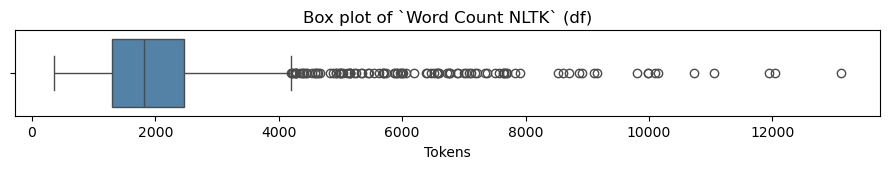

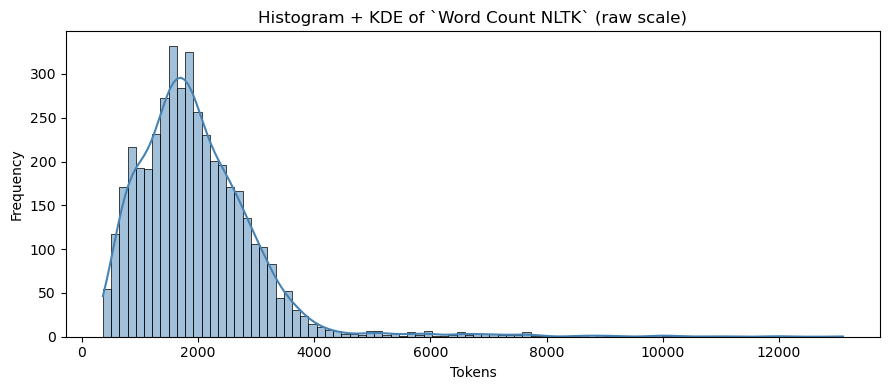

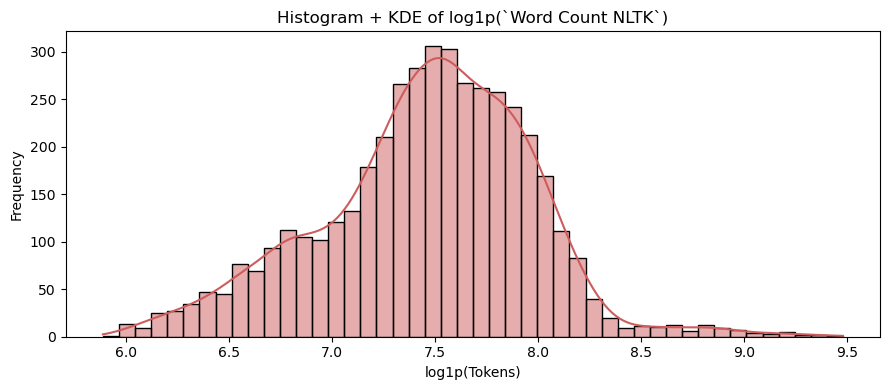

In [21]:
# Select the series
series = df['Word Count NLTK'].dropna()

# Summary stats
mean_val = series.mean()
std_val = series.std(ddof=1)  # sample standard deviation
desc = series.describe()  # count, mean, std, min, 25%, 50%, 75%, max

print("Descriptive statistics for `Word Count NLTK`:")
print(f"- Count: {int(desc['count'])}")
print(f"- Mean: {mean_val:.2f}")
print(f"- Std (sample): {std_val:.2f}")
print(f"- Min: {int(desc['min'])}")
print(f"- Q1 (25%): {desc['25%']:.2f}")
print(f"- Median (50%): {desc['50%']:.2f}")
print(f"- Q3 (75%): {desc['75%']:.2f}")
print(f"- Max: {int(desc['max'])}")

# IQR-based outlier detection
q1, q3 = series.quantile([0.25, 0.75])
iqr = q3 - q1
lower_fence = q1 - 1.5 * iqr
upper_fence = q3 + 1.5 * iqr

outlier_mask = (series < lower_fence) | (series > upper_fence)
outliers = (
    df.loc[outlier_mask, ['File', 'Text ID', 'Year', 'Word Count NLTK']]
    .sort_values('Word Count NLTK')
    .reset_index(drop=True)
)

print(f"\nIQR outlier thresholds:")
print(f"- Lower fence: {lower_fence:.2f}")
print(f"- Upper fence: {upper_fence:.2f}")
print(f"Outliers found: {len(outliers)}")
display(outliers)

# Box plot
plt.figure(figsize=(9, 1.8))
sns.boxplot(x=series, color='steelblue')
plt.title('Box plot of `Word Count NLTK` (df)')
plt.xlabel('Tokens')
plt.tight_layout()

# Saving the plot
plt.savefig(f"{output_directory}/{dataset_filename_2}_boxplot.png", dpi=300)

plt.show()

# Raw scale: Histogram + KDE
plt.figure(figsize=(9, 4))
sns.histplot(series, bins='auto', kde=True, color='steelblue')
plt.title('Histogram + KDE of `Word Count NLTK` (raw scale)')
plt.xlabel('Tokens')
plt.ylabel('Frequency')
plt.tight_layout()

# Saving the plot
plt.savefig(f"{output_directory}/{dataset_filename_2}_histogram.png", dpi=300)

plt.show()

# Log scale via transformation: Histogram + KDE
log_series = np.log1p(series)  # log(1 + x) to handle zeros safely
plt.figure(figsize=(9, 4))
sns.histplot(log_series, bins='auto', kde=True, color='indianred')
plt.title('Histogram + KDE of log1p(`Word Count NLTK`)')
plt.xlabel('log1p(Tokens)')
plt.ylabel('Frequency')
plt.tight_layout()

# Saving the plot
plt.savefig(f"{output_directory}/{dataset_filename_2}_histogram_log_scale.png", dpi=300)

plt.show()

## Export to a file

In [22]:
df[['Root Directory', 'File', 'File Path', 'Text ID', 'Year', 'Word Count NLTK', 'Text']].to_json(f"{output_directory}/{dataset_filename_2}.jsonl", orient='records', lines=True)